# 01 — ETL Pipeline

Load all 9 Olist CSVs → clean → join into a master DataFrame → persist to SQLite.



## 1. Imports

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
sys.path.append("../src")
print("Imports OK")

Imports OK


## 2. Load Raw CSVs

All 9 tables from the Olist dataset.

In [2]:
orders_raw  = pd.read_csv("../data/raw/olist_orders_dataset.csv")
items       = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
customers   = pd.read_csv("../data/raw/olist_customers_dataset.csv")
products    = pd.read_csv("../data/raw/olist_products_dataset.csv")
sellers     = pd.read_csv("../data/raw/olist_sellers_dataset.csv")          # NEW
payments    = pd.read_csv("../data/raw/olist_order_payments_dataset.csv")
reviews     = pd.read_csv("../data/raw/olist_order_reviews_dataset.csv")
try:
    translation = pd.read_csv("../data/raw/product_category_name_translation.csv")
except FileNotFoundError:
    translation = None
    print("Warning: category translation not found — will use Portuguese names")

for name, df in [("orders", orders_raw), ("items", items), ("customers", customers),
                 ("products", products), ("sellers", sellers), ("payments", payments),
                 ("reviews", reviews)]:
    print(f"{name:12s}: {df.shape[0]:>7,} rows  {df.shape[1]:>2} cols")

orders      :  99,441 rows   8 cols
items       : 112,650 rows   7 cols
customers   :  99,441 rows   5 cols
products    :  32,951 rows   9 cols
sellers     :   3,095 rows   4 cols
payments    : 103,886 rows   5 cols
reviews     :  99,224 rows   7 cols


## 3. Data Audit

In [3]:
# Null summary across all tables
for name, df in [("orders", orders_raw), ("items", items), ("customers", customers),
                 ("products", products), ("sellers", sellers), ("payments", payments),
                 ("reviews", reviews)]:
    nulls = df.isnull().sum()
    if nulls.any():
        print(f"{name}:")
        print(nulls[nulls > 0])

orders:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64
products:
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64
reviews:
review_comment_title      87656
review_comment_message    58247
dtype: int64


## 4. Clean Orders

Parse timestamps → derive , , , .

In [4]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

orders = orders_raw.copy()
for col in date_cols:
    if col in orders.columns:
        orders[col] = pd.to_datetime(orders[col], errors="coerce")

orders["delivery_days"] = (
    orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]
).dt.days

orders["delivery_delay_days"] = (
    orders["order_delivered_customer_date"] - orders["order_estimated_delivery_date"]
).dt.days

orders["is_late"]    = orders["delivery_delay_days"] > 0
orders["order_month"] = orders["order_purchase_timestamp"].dt.to_period("M").astype(str)
orders["order_dow"]   = orders["order_purchase_timestamp"].dt.day_name()

orders[["order_purchase_timestamp", "order_delivered_customer_date",
         "delivery_days", "is_late", "order_month", "order_dow"]].head()

,order_purchase_timestamp,order_delivered_customer_date,delivery_days,is_late,order_month,order_dow
0,2017-10-02 10:56:33,2017-10-10 21:25:13,8.0,False,2017-10,Monday
1,2018-07-24 20:41:37,2018-08-07 15:27:45,13.0,False,2018-07,Tuesday
2,2018-08-08 08:38:49,2018-08-17 18:06:29,9.0,False,2018-08,Wednesday
3,2017-11-18 19:28:06,2017-12-02 00:28:42,13.0,False,2017-11,Saturday
4,2018-02-13 21:18:39,2018-02-16 18:17:02,2.0,False,2018-02,Tuesday


In [5]:
orders.to_csv("../data/processed/orders_clean.csv", index=False)
print(f"Saved orders_clean.csv — {orders.shape}")

Saved orders_clean.csv — (99441, 13)


## 5. Fix Products Column Typos

Olist ships two misspelled column names ( → ).

In [6]:
products.rename(columns={
    "product_name_lenght":        "product_name_length",
    "product_description_lenght": "product_description_length",
}, inplace=True)
products["product_category_name"] = products["product_category_name"].fillna("Unknown")
print(products.columns.tolist())

['product_id', 'product_category_name', 'product_name_length', 'product_description_length', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']


## 6. Sellers

Carry seller city/state into the master table for supply-side geo analysis.

In [7]:
sellers.rename(columns={
    "seller_city":  "seller_city",
    "seller_state": "seller_state",
}, inplace=True)
print(sellers.head())
print(sellers.isnull().sum())

                          seller_id  seller_zip_code_prefix  \
0  3442f8959a84dea7ee197c632cb2df15                   13023   
1  d1b65fc7debc3361ea86b5f14c68d2e2                   13844   
2  ce3ad9de960102d0677a81f5d0bb7b2d                   20031   
3  c0f3eea2e14555b6faeea3dd58c1b1c3                    4195   
4  51a04a8a6bdcb23deccc82b0b80742cf                   12914   

         seller_city seller_state  
0           campinas           SP  
1         mogi guacu           SP  
2     rio de janeiro           RJ  
3          sao paulo           SP  
4  braganca paulista           SP  
seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64


## 7. Aggregate Payments

Collapse multi-row payments to one row per order.

In [8]:
payments_agg = payments.groupby("order_id").agg(
    payment_value        = ("payment_value",        "sum"),
    payment_installments = ("payment_installments", "max"),
    payment_type         = ("payment_type", lambda s: s.mode().iat[0] if len(s) else None),
    n_payments           = ("payment_sequential",   "max"),
).reset_index()
print(payments_agg.shape)
payments_agg.head()

(99440, 5)


,order_id,payment_value,payment_installments,payment_type,n_payments
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,credit_card,1
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,credit_card,1
2,000229ec398224ef6ca0657da4fc703e,216.87,5,credit_card,1
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,credit_card,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,credit_card,1


## 8. Aggregate Reviews

In [9]:
reviews_agg = reviews.groupby("order_id").agg(
    review_score = ("review_score", "mean")
).reset_index()
print(reviews_agg.shape)
reviews_agg.head()

(98673, 2)


,order_id,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,5.0
1,00018f77f2f0320c557190d7a144bdd3,4.0
2,000229ec398224ef6ca0657da4fc703e,5.0
3,00024acbcdf0a6daa1e931b038114c75,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0


## 9. Build Master Table

Join all tables: items → orders → customers → sellers → payments → products → reviews → translation.

In [10]:
master = (
    items
    .merge(orders,        on="order_id",   how="left")
    .merge(customers,     on="customer_id", how="left")
    .merge(sellers,       on="seller_id",  how="left")   # NEW: seller city/state
    .merge(payments_agg,  on="order_id",   how="left")
    .merge(products,      on="product_id", how="left")
    .merge(reviews_agg,   on="order_id",   how="left")
)

# Category translation (Portuguese → English)
if translation is not None:
    master = master.merge(translation, on="product_category_name", how="left")
    master["product_category_name"] = (
        master["product_category_name_english"].fillna(master["product_category_name"])
    )
    master.drop(columns=["product_category_name_english"], inplace=True, errors="ignore")

print(f"Master shape: {master.shape}")
master.head()

Master shape: (112650, 39)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,n_payments,product_category_name,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,1.0,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,5.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,1.0,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,4.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,1.0,furniture_decor,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,5.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,1.0,perfumery,42.0,480.0,1.0,200.0,16.0,10.0,15.0,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,1.0,garden_tools,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,5.0


## 10. Feature Engineering

All four derived columns required by the project plan.

### 10a. Revenue

In [11]:
master["revenue"] = master["price"].fillna(0) + master["freight_value"].fillna(0)
master[["price", "freight_value", "revenue"]].head()

,price,freight_value,revenue
0,58.90,13.29,72.19
1,239.90,19.93,259.83
2,199.00,17.87,216.87
3,12.99,12.79,25.78
4,199.90,18.14,218.04


### 10b. Profit Margin

Guard against divide-by-zero when .

In [12]:
safe_price = master["price"].replace(0, pd.NA)
master["profit_margin"] = (
    (master["price"] - master["freight_value"]) / safe_price
) * 100

master["profit_margin"].describe()

count    112650.000000
mean         67.913645
std          34.989368
min       -2523.529412
25%          60.696379
50%          76.864376
75%          86.596634
max         100.000000
Name: profit_margin, dtype: float64

### 10c. Item Count + Order Size Bucket

In [13]:
item_counts = master.groupby("order_id").size().reset_index(name="item_count")
master = master.merge(item_counts, on="order_id", how="left")

def classify_order_size(x):
    if x == 1:    return "Small"
    elif x <= 3:  return "Medium"
    else:         return "Large"

master["order_size"] = master["item_count"].apply(classify_order_size)
master[["order_id", "item_count", "order_size"]].drop_duplicates("order_id").head(10)

,order_id,item_count,order_size
0,00010242fe8c5a6d1ba2dd792cb16214,1,Small
1,00018f77f2f0320c557190d7a144bdd3,1,Small
2,000229ec398224ef6ca0657da4fc703e,1,Small
3,00024acbcdf0a6daa1e931b038114c75,1,Small
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,Small
5,00048cc3ae777c65dbb7d2a0634bc1ea,1,Small
6,00054e8431b9d7675808bcb819fb4a32,1,Small
7,000576fe39319847cbb9d288c5617fa6,1,Small
8,0005a1a1728c9d785b8e2b08b904576c,1,Small
9,0005f50442cb953dcd1d21e1fb923495,1,Small


### 10d. Review Sentiment

 = 4–5 ·  = 3 ·  = 1–2

In [14]:
def classify_sentiment(score):
    if pd.isna(score):  return pd.NA
    elif score >= 4:    return "positive"
    elif score == 3:    return "neutral"
    else:               return "negative"

master["review_sentiment"] = master["review_score"].apply(classify_sentiment)
master["review_sentiment"].value_counts(dropna=False)

review_sentiment
positive    84317
negative    18007
neutral      9384
NaN           942
Name: count, dtype: int64

## 11. Sanity Checks

In [15]:
print("Master columns:", master.columns.tolist())
print("Null counts (key cols):")
key_cols = ["order_id", "customer_id", "seller_id", "product_id",
            "revenue", "profit_margin", "item_count", "order_size",
            "review_score", "review_sentiment"]
print(master[key_cols].isnull().sum())

Master columns: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_days', 'delivery_delay_days', 'is_late', 'order_month', 'order_dow', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'payment_value', 'payment_installments', 'payment_type', 'n_payments', 'product_category_name', 'product_name_length', 'product_description_length', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'review_score', 'revenue', 'profit_margin', 'item_count', 'order_size', 'review_sentiment']
Null counts (key cols):
order_id              0
customer_id           0
seller_id             0
product_id            0
revenue       

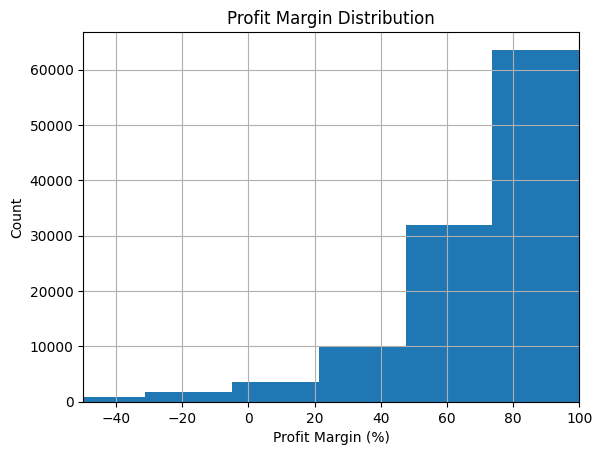

In [16]:
# Profit margin distribution (clipped for readability)
master["profit_margin"].hist(bins=100)
plt.xlim(-50, 100)
plt.title("Profit Margin Distribution")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Count")
plt.show()

## 12. Save Processed CSVs

In [17]:
import os
os.makedirs("../data/processed", exist_ok=True)

master.to_csv("../data/processed/master.csv", index=False)
orders.to_csv("../data/processed/orders_clean.csv", index=False)
print("Saved master.csv and orders_clean.csv")

Saved master.csv and orders_clean.csv


## 13. Load to SQLite

All 7 tables written — previously only 3 were persisted.

In [18]:
import os
os.makedirs("../data", exist_ok=True)
engine = create_engine("sqlite:///../data/ecommerce.db")

tables = {
    "master":    master,
    "orders":    orders,
    "customers": customers,
    "products":  products,
    "sellers":   sellers,      # NEW
    "payments":  payments,     # NEW (raw, pre-aggregation)
    "reviews":   reviews,      # NEW
}

for table_name, df in tables.items():
    df.to_sql(table_name, engine, if_exists="replace", index=False)
    print(f"  wrote {len(df):>7,} rows → {table_name}")

print("Database ready:", os.path.abspath("../data/ecommerce.db"))

  wrote 112,650 rows → master
  wrote  99,441 rows → orders
  wrote  99,441 rows → customers
  wrote  32,951 rows → products
  wrote   3,095 rows → sellers
  wrote 103,886 rows → payments
  wrote  99,224 rows → reviews
Database ready: /Users/harshilarora/Documents/ecommerce-pipeline/data/ecommerce.db


## 14. Verify Database

In [19]:
import sqlite3
con = sqlite3.connect("../data/ecommerce.db")
cur = con.cursor()
cur.execute("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name")
print("Tables in DB:", [r[0] for r in cur.fetchall()])
result = con.execute("SELECT COUNT(*) FROM master").fetchone()[0]
print(f"master row count: {result:,}")
con.close()

Tables in DB: ['customers', 'master', 'orders', 'payments', 'products', 'reviews', 'sellers']
master row count: 112,650
